# Chronos 2 Inference Pipeline
Use this file to test out different feature sets with Chronos-2.
Official documentation: https://github.com/amazon-science/chronos-forecasting

Run the following:
```
pip install 'chronos-forecasting>=2.0' 'pandas[pyarrow]' 'matplotlib' 'scikit-learn' 'numpy'
```


In [14]:
# Core
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chronos - 2
from chronos import Chronos2Pipeline

In [16]:
# ============================
# User Config (EDIT ME)
# ============================

# CSV Loading
# Use forward slashes or escaped backslashes to avoid unicode-escape issues on Windows paths
csv_path = "alphavantage_data/UBS_daily_data.csv"
date_col = "date"
id_col = None #Set to column name if you have multiple series
default_id_value = "series_1" # Use this if id_col = None

# Target
target_col = "high"

# Features
feature_cols = ["open", "close", "low", "volume"] # List your feature columns here

# Business Days reindexing
freq = "B"
reindex_start = None
reindex_end = None

# Train / Test split
split_start_date = "2020-01-01" # Train starts here
train_fraction = 0.80 # first 80% context, last 20% forecast horizon

# Chronos-2 model settings
device = "cpu" #if you can use a GPU, enter "cuda"


In [17]:
# ============================
# Load CSV and Basic Cleaing
# ============================

# load csv
df = pd.read_csv(csv_path)

# ensure datetime column is parsed correctly
df[date_col] = pd.to_datetime(df[date_col])

# Sort by time
df = df.sort_values(date_col).reset_index(drop=True)

# If there is no id column, create a single-id series
if id_col is None:
    df["id"] = default_id_value
    id_col = "id"


# Keep only needed columns
keep_cols = [id_col, date_col, target_col] + feature_cols
df = df[keep_cols].copy()

df.head()

,id,date,high,open,close,low,volume
0,series_1,2014-11-21,17.47,17.47,17.3900,17.3900,7000
1,series_1,2014-11-24,17.99,17.55,17.5800,17.3800,6832
2,series_1,2014-11-25,17.56,17.56,17.4835,17.4835,4426
3,series_1,2014-11-26,23.20,17.55,23.2000,17.5200,2817
4,series_1,2014-11-28,18.13,18.09,17.9900,17.9600,111605


In [18]:
# ==========================================
# BUSINESS-DAY INDEX + REINDEXING (REQUIRED)
# (done per series to keep Chronos freq valid)
# ==========================================

value_cols = [target_col] + feature_cols

pieces = []

for sid, g in df.groupby(id_col):
    # Sort and remove duplicate timestamps (needed for stable frequency)
    g = g.sort_values(date_col).drop_duplicates(subset=[date_col])

    # Set timestamp index
    g = g.set_index(date_col)

    # Determine business-day range per series
    start_date = reindex_start if reindex_start is not None else g.index.min()
    end_date   = reindex_end   if reindex_end   is not None else g.index.max()
    bdays_idx = pd.date_range(start=start_date, end=end_date, freq=freq)

    # Reindex to business days -> may create NaNs
    g = g.reindex(bdays_idx)

    # Fill ONLY the NaNs created by reindexing
    # This keeps a fully regular business-day calendar.
    # Note!: Currently uses a simple Forward Fill - has to be changed as soon as a better solution is found.
    g[value_cols] = g[value_cols].ffill()

    # Restore id + timestamp column
    g[id_col] = sid
    g.index.name = date_col
    pieces.append(g.reset_index())

# Combine all series back together
df = pd.concat(pieces, ignore_index=True)

print(df.head(10))
print(df.tail(10))


        date        id   high   open    close      low    volume
0 2014-11-21  series_1  17.47  17.47  17.3900  17.3900    7000.0
1 2014-11-24  series_1  17.99  17.55  17.5800  17.3800    6832.0
2 2014-11-25  series_1  17.56  17.56  17.4835  17.4835    4426.0
3 2014-11-26  series_1  23.20  17.55  23.2000  17.5200    2817.0
4 2014-11-27  series_1  23.20  17.55  23.2000  17.5200    2817.0
5 2014-11-28  series_1  18.13  18.09  17.9900  17.9600  111605.0
6 2014-12-01  series_1  18.13  18.10  17.9000  17.8200  450011.0
7 2014-12-02  series_1  18.02  17.96  18.0000  17.8800  567380.0
8 2014-12-03  series_1  18.19  18.17  18.1100  18.0200  798088.0
9 2014-12-04  series_1  18.22  18.14  18.1600  18.0900  804024.0
           date        id     high   open  close     low     volume
2860 2025-11-07  series_1  38.3100  37.61  38.31  37.490  1501139.0
2861 2025-11-10  series_1  38.5100  38.36  38.43  38.175  2133234.0
2862 2025-11-11  series_1  39.1350  38.94  38.98  38.910  1332076.0
2863 2025-11-

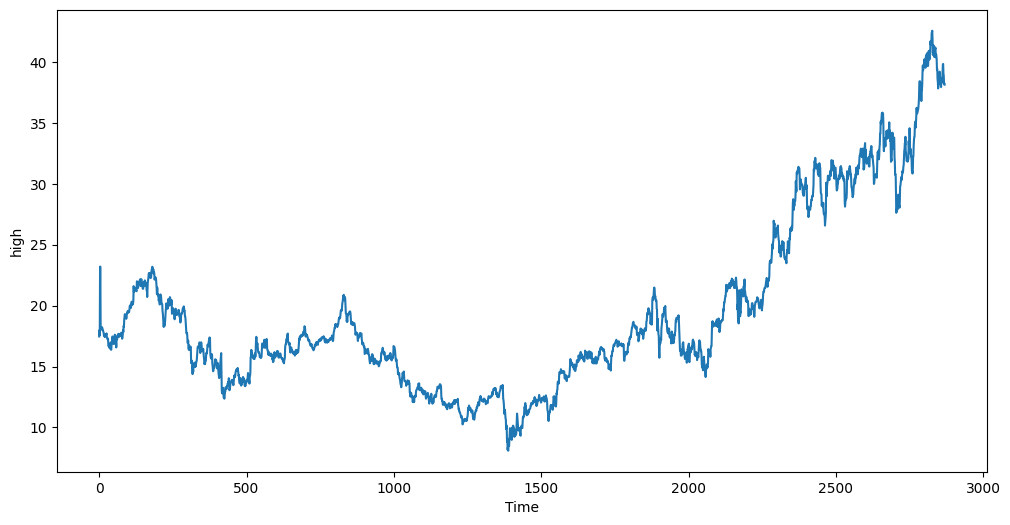

In [19]:
# Optional Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[target_col]) # Use df.index instead of df['Time']
plt.xlabel('Time')
plt.ylabel(target_col)
plt.show()

In [20]:
# ==========================================
# Define context_df + future_df
# ==========================================

# Make sure data is perfectly ordered before splitting
df = df.sort_values([id_col, date_col]).reset_index(drop=True)

# Filter dataset from split_start_date onwards
df_split = df[df[date_col] >= pd.Timestamp(split_start_date)]
df_split = df_split.sort_values(date_col).reset_index(drop=True)

# Compute split points
n_total = len(df_split)
n_train = int(np.floor(train_fraction * n_total))

context_df = df_split.iloc[:n_train].copy()
future_df = df_split.iloc[n_train:].copy()

# Show sizes
print("Context length:", len(context_df))
print("Future length :", len(future_df))
print("----- Context DF ----- ")
print(context_df.head())
print(context_df.tail())
print("----- Future DF ----- ")
print(future_df.head())
print(future_df.tail())

Context length: 1229
Future length : 308
----- Context DF ----- 
        date        id    high   open  close     low     volume
0 2020-01-01  series_1  12.590  12.54  12.58  12.500  2062993.0
1 2020-01-02  series_1  12.920  12.70  12.92  12.670  3352185.0
2 2020-01-03  series_1  12.770  12.68  12.71  12.650  2627427.0
3 2020-01-06  series_1  12.700  12.60  12.68  12.580  2318490.0
4 2020-01-07  series_1  12.985  12.92  12.94  12.863  4237634.0
           date        id    high   open  close    low     volume
1224 2024-09-10  series_1  28.900  28.90  28.63  28.33  2268046.0
1225 2024-09-11  series_1  29.070  28.81  29.00  28.42  1980026.0
1226 2024-09-12  series_1  29.095  28.86  28.98  28.68  1403368.0
1227 2024-09-13  series_1  29.665  29.38  29.59  29.38  1252106.0
1228 2024-09-16  series_1  29.830  29.65  29.79  29.60  1396216.0
----- Future DF ----- 
           date        id    high   open  close     low     volume
1229 2024-09-17  series_1  30.050  30.00  29.76  29.665  1003584.

In [21]:
# ===========================
# Load Chronos-2 Model
# ===========================

pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map = device,
)

#### Predict the full horizon in one go

In [49]:
# ======================================
# Build  Chronos and inference
# ======================================

"""
Chronos-2 can take two seperate dfs as inputs to perform forecasting. 
The context_df and the future_df. Only the context_df is mandatory.

The context_df includes:
- historical portion of data - including target, features, id, timestamp - that chronos uses to understand past behaviour and patterns.
- must include target
- can include past known covariates and features

The future_df includes:
- only timestamps and optional future-known covaraites for which predictions should be generated
- does NOT inlude the target
- typically represents the forecast horizon --> the part after the split
"""

# prediction length
pred_len = len(future_df)
if pred_len <= 0:
    raise ValueError("future_df is empty, no prediction possible.")

# Build columns sets for Chronos
# Note: in context_cols you have everything needed. in future_cols you just leave out the target_col
context_cols = [id_col, date_col, target_col] + feature_cols
future_cols = [id_col, date_col] + feature_cols

context_df_chronos = context_df[context_cols].reset_index(drop=True)
future_df_chronos = future_df[future_cols].reset_index(drop=True)

print(context_df_chronos.head())
print(future_df_chronos.head())

# Run Chronos inference
pred_df = pipeline.predict_df(
    context_df_chronos,
    #future_df = future_df_chronos,
    prediction_length= pred_len,
    quantile_levels = [0.1, 0.5, 0.9],
    id_column = id_col,
    timestamp_column = date_col,
    target = target_col
)

pred_df.head()


         id       date    high   open  close     low     volume
0  series_1 2020-01-01  12.590  12.54  12.58  12.500  2062993.0
1  series_1 2020-01-02  12.920  12.70  12.92  12.670  3352185.0
2  series_1 2020-01-03  12.770  12.68  12.71  12.650  2627427.0
3  series_1 2020-01-06  12.700  12.60  12.68  12.580  2318490.0
4  series_1 2020-01-07  12.985  12.92  12.94  12.863  4237634.0
         id       date   open  close     low     volume
0  series_1 2024-09-17  30.00  29.76  29.665  1003584.0
1  series_1 2024-09-18  29.91  29.91  29.740  1321264.0
2  series_1 2024-09-19  30.33  30.40  30.100  1121915.0
3  series_1 2024-09-20  29.96  29.90  29.705  1397232.0
4  series_1 2024-09-23  30.11  30.22  30.100   950498.0


c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,id,date,target_name,predictions,0.1,0.5,0.9
0,series_1,2024-09-17,high,29.653801,28.847908,29.653801,30.280350
1,series_1,2024-09-18,high,29.709276,28.868822,29.709276,30.497341
2,series_1,2024-09-19,high,29.706230,28.548294,29.706230,30.641260
3,series_1,2024-09-20,high,29.650234,28.486919,29.650234,30.753967
4,series_1,2024-09-23,high,29.686043,28.331402,29.686043,30.926104


In [50]:
# ======================================
# Merge predictions with the true values
# ======================================

results = pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

y_true = results[target_col].astype(float)
y_pred_median = results["0.5"].astype(float)

results.head()


,id,date,target_name,predictions,0.1,0.5,0.9,high
0,series_1,2024-09-17,high,29.653801,28.847908,29.653801,30.280350,30.050
1,series_1,2024-09-18,high,29.709276,28.868822,29.709276,30.497341,30.320
2,series_1,2024-09-19,high,29.706230,28.548294,29.706230,30.641260,30.455
3,series_1,2024-09-20,high,29.650234,28.486919,29.650234,30.753967,30.020
4,series_1,2024-09-23,high,29.686043,28.331402,29.686043,30.926104,30.290


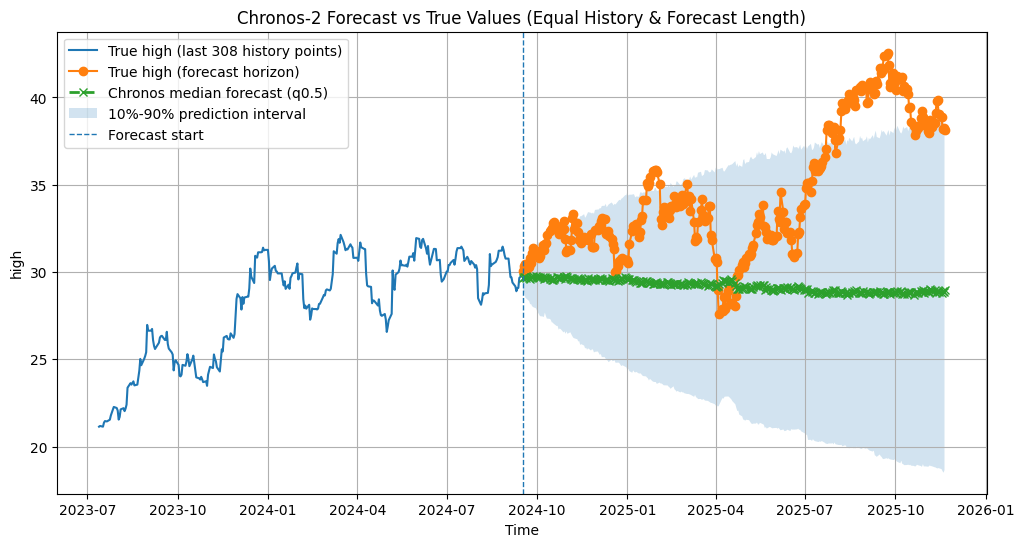

In [51]:
# ===========================
# Plot
# ===========================

# How many steps were predicted
pred_len = len(results)

# Take exactly the last pred_len historical points
hist_part = context_df[[date_col, target_col]].copy()
hist_part = hist_part.sort_values(date_col).tail(pred_len)

# True future (for the forecast horizon)
true_future_part = future_df[[date_col, target_col]].copy()
true_future_part = true_future_part.sort_values(date_col).head(pred_len)

# Forecast (median + optional intervals)
forecast_part = results[[date_col, "0.5"]].copy().sort_values(date_col)

plt.figure(figsize=(12, 6))

# Plot historical true (same length as forecast)
plt.plot(
    hist_part[date_col],
    hist_part[target_col].astype(float),
    label=f"True {target_col} (last {pred_len} history points)",
    linewidth=1.5
)

# Plot true future values
plt.plot(
    true_future_part[date_col],
    true_future_part[target_col].astype(float),
    label=f"True {target_col} (forecast horizon)",
    linewidth=1.5,
    marker="o"
)

# Plot median forecast
plt.plot(
    forecast_part[date_col],
    forecast_part["0.5"].astype(float),
    label="Chronos median forecast (q0.5)",
    linestyle="--",
    linewidth=2,
    marker="x"
)

# Optional uncertainty band if available
if "0.1" in results.columns and "0.9" in results.columns:
    plt.fill_between(
        results[date_col],
        results["0.1"].astype(float),
        results["0.9"].astype(float),
        alpha=0.2,
        label="10%-90% prediction interval"
    )

# Vertical line at forecast start
split_ts = true_future_part[date_col].min()
plt.axvline(split_ts, linestyle="--", linewidth=1, label="Forecast start")

plt.title("Chronos-2 Forecast vs True Values (Equal History & Forecast Length)")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()


In [48]:
# ===========================
# Metrics
# ===========================

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred_median))

# MAE
mae = mean_absolute_error(y_true, y_pred_median)

# Adjusted R Squared
r2 = r2_score(y_true, y_pred_median)
n = len(y_true)
p = len(feature_cols)

if n - p - 1 > 0:
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
else:
    adj_r2 = np.nan  # not defined if too few samples vs features

# Quantile Loss (Pinball loss)
valid_mask = ~y_true.isna()
def pinball_loss(y, yhat, q):
    diff = y - yhat
    return np.mean(np.maximum(q * diff, (q - 1)* diff))

quantile_losses = {}
for q in [0.1, 0.5, 0.9]:
    q_str = str(q)
    yhat_q = results[q_str].astype(float)[valid_mask]
    quantile_losses[q] = pinball_loss(y_true.values, yhat_q.values, q)

# CRPS approximation
qs = np.array(sorted(quantile_losses.keys()))
Ls = np.array([quantile_losses[q] for q in qs])
crps = 2 * np.trapezoid(Ls, qs)

# Print
print("CRPS (approx.):", crps)
print("RMSE:", rmse)
print("MAE:", mae)
print("Adjusted R^2:", adj_r2)
print("Quantile Losses:")
for q, Lq in quantile_losses.items():
    print(f"--> q={q}: {Lq}")


CRPS (approx.): 0.20652661013912843
RMSE: 0.4869427392711228
MAE: 0.36335281241280687
Adjusted R^2: 0.982623733210049
Quantile Losses:
--> q=0.1: 0.08499453517765192
--> q=0.5: 0.18167640620640343
--> q=0.9: 0.06796917775736225


### More realistic approach - Rolling backtest
You only predict the next day. You repeat that until you have predicted the whole prediction horizon.

In [ ]:
# ==========================================
# Rolling Backtest: 1-Schritt-Vorhersage
# ==========================================

"""
Idee:
- Wir simulieren, dass wir jeden Tag nur die Daten bis gestern kennen.
- Wir starten mit dem ursprünglichen context_df.
- Für jeden Tag im future_df:
    - Kontext = context_df + alle bisher schon beobachteten "Future"-Tage (mit echten Targets)
    - Wir rufen Chronos mit prediction_length=1 und OHNE future_df auf.
    - Wir speichern die 1-Schritt-Vorhersage und gehen einen Tag weiter.
"""

# Sicherstellen, dass context_df und future_df existieren
assert 'context_df' in globals(), "context_df ist nicht definiert. Bitte zuerst die Split-Zelle ausführen."
assert 'future_df' in globals(), "future_df ist nicht definiert. Bitte zuerst die Split-Zelle ausführen."

# Zusammenbau von Train + Test (nur zur sauberen Zeit-Reihenfolge)
df_roll = pd.concat([context_df, future_df], ignore_index=True)
df_roll = df_roll.sort_values(date_col).reset_index(drop=True)

initial_context_len = len(context_df)
horizon_len = len(future_df)

print(f"Initiale Kontext-Länge: {initial_context_len}")
print(f"Rolling-Horizont (Anzahl Tage im future_df): {horizon_len}")

rolling_pred_list = []

for step in range(horizon_len):
    # Kontext: alle Daten bis einschließlich Tag t-1
    end_idx = initial_context_len + step  # slicing ist exklusiv, also bis end_idx-1
    context_step = df_roll.iloc[:end_idx].copy()
    
    # Für Chronos: gleiche Spalten wie bei deiner normalen Inferenz
    context_step_chronos = context_step[[id_col, date_col, target_col] + feature_cols].reset_index(drop=True)
    
    # 1-Schritt-Vorhersage ohne future_df
    step_pred_df = pipeline.predict_df(
        context_step_chronos,
        prediction_length = 1,
        quantile_levels   = [0.1, 0.5, 0.9],
        id_column         = id_col,
        timestamp_column  = date_col,
        target            = target_col
    )
    
    # Schritt speichern
    rolling_pred_list.append(step_pred_df)
    
    # Optional: Fortschritt anzeigen
    if (step + 1) % 10 == 0 or step == horizon_len - 1:
        print(f"Rolling Step {step + 1}/{horizon_len} fertig.")

# Alle 1-Schritt-Predictions hintereinander
rolling_pred_df = pd.concat(rolling_pred_list, ignore_index=True)

print("Rolling-Predictions (nur Vorhersagen):")
print(rolling_pred_df.head())
print(rolling_pred_df.tail())

# Nun joinen wir – analog zu deiner normalen Pipeline – die echten Werte aus future_df hinzu
results_rolling = rolling_pred_df.merge(
    future_df[[id_col, date_col, target_col]],
    on=[id_col, date_col],
    how="left"
)

# y_true und Median-Prediction für Rolling-Backtest
y_true_rolling = results_rolling[target_col].astype(float)
y_pred_median_rolling = results_rolling["0.5"].astype(float)

print("Rolling-Ergebnis (mit True-Werten):")
print(results_rolling.head())
print(results_rolling.tail())


c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step 1/308 done


c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Users\Gil\SAI1\stonksAI\stonk

Step 11/308 done


c:\Users\Gil\SAI1\stonksAI\stonksai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 